In [1]:
import scqubits
import numpy as np
from scipy.optimize import minimize
import sys
sys.path.append('../utils/')
from utils_models import *

In [42]:
EJ = 4
EC = EJ/2.7
EL = EJ/40

qubit_level = 40


def get_shift_accurate(ele,omega_i, omega_j, omega_r):
    return abs(ele)**2 / (omega_j-omega_i-omega_r) - abs(ele)**2 / (omega_i-omega_j-omega_r)


qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
evals = qbt.eigenvals(qubit_level)
elements = qbt.matrixelement_table('n_operator',evals_count = qubit_level)

def shift_diff(x):
    Er = x[0]

    shifts_from_zero = [get_shift_accurate(elements[0,ql2],evals[ql2],evals[0],Er) for ql2 in range(qubit_level)] 
    shift_from_zero = sum(shifts_from_zero)
    shifts_from_two = [get_shift_accurate(elements[2,ql2],evals[ql2],evals[2],Er) for ql2 in range(qubit_level)] 
    shift_from_two = sum(shifts_from_two)
    return abs(shift_from_zero-shift_from_two)

initial_guess = [11]

# Call the optimizer
result = minimize(shift_diff, initial_guess, method='Nelder-Mead')

print("Result:", result)
print("Optimal solution:", result.x)
print("Objective value:", result.fun)


Result:        message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 3.5373135628784247e-07
             x: [ 1.097e+01]
           nit: 14
          nfev: 28
 final_simplex: (array([[ 1.097e+01],
                       [ 1.097e+01]]), array([ 3.537e-07,  7.795e-07]))
Optimal solution: [10.96636353]
Objective value: 3.5373135628784247e-07


In [3]:
evals[2]-evals[1]

0.030171702197517747

In [7]:
qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
evals = qbt.eigenvals(qubit_level)


1.4045228780350683

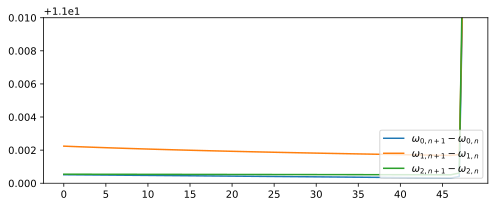

In [49]:
EJ = 4
EC = EJ/2.7
EL = EJ/40


Er = 11# result.x[0]
g = 0.3

max_ol = 50
max_ql = 24
system = FluxoniumOscillatorSystem(
    EJ = EJ,
    EC = EC,
    EL = EL,
    Er = Er,
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    # kappa = 0.004,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '0,2'
    )
energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]

plt.figure(figsize = (8,3))
n_osc_lvls = max_ol-1
dressed_osc_frequencies = [[] for _ in range(3)]
for j in [0,1,2]:
    for i in range(0,max_ol-1):
        dressed_osc_frequencies[j].append(dressed_ener(j,i+1)-dressed_ener(j,i))   
for j in [0,1,2]:
    plt.plot(list(range(max_ol-1))[:n_osc_lvls], dressed_osc_frequencies[j][:n_osc_lvls],label=rf'$\omega_{{{j},n+1}} - \omega_{{{j},n}}$')

plt.xticks(list(range(n_osc_lvls))[::5])
plt.ylim(Er, Er+0.01)
# plt.ylim(7.9,7.92)
plt.legend(loc='lower right')

In [51]:
dressed_ener(2,0)-dressed_ener(1,0)

0.04015074197528057

In [50]:
dressed_ener(1,1)-dressed_ener(1,0), dressed_ener(0,1)-dressed_ener(0,0), dressed_ener(2,1)-dressed_ener(2,0)

(11.002240764317005, 11.000514574767823, 11.000545656562917)

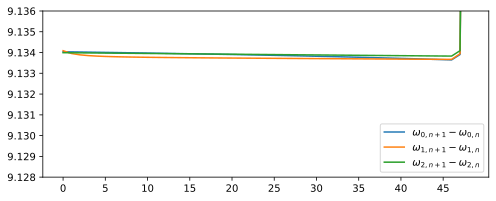

In [47]:
EJ = 4
EC = EJ/4.2
EL = EJ/20.85

Er = 9.132# result.x[0]
g = 0.3

max_ol = 50
max_ql = 24
system = FluxoniumOscillatorSystem(
    EJ = EJ,
    EC = EC,
    EL = EL,
    Er = Er,
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    # kappa = 0.004,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '0,2'
    )
energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]

plt.figure(figsize = (8,3))
n_osc_lvls = max_ol-1
dressed_osc_frequencies = [[] for _ in range(3)]
for j in [0,1,2]:
    for i in range(0,max_ol-1):
        dressed_osc_frequencies[j].append(dressed_ener(j,i+1)-dressed_ener(j,i))   
for j in [0,1,2]:
    plt.plot(list(range(max_ol-1))[:n_osc_lvls], dressed_osc_frequencies[j][:n_osc_lvls],label=rf'$\omega_{{{j},n+1}} - \omega_{{{j},n}}$')

plt.xticks(list(range(n_osc_lvls))[::5])
plt.ylim(Er-0.004, Er+0.004)
# plt.ylim(7.9,7.92)
plt.legend(loc='lower right')